In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_excel('dataset.xlsx')

In [3]:
df.head()

,Station_ID,Year,Quarter,Log_RV_PPE,Log_Depreciation_PPE,Log_Total_NCA,Log_Total_inventory,Log_TR,Log_cash,Log_Total_CA,...,Equity_ratio,Debt to equity,Debt ratio,ROA,ROE,Net_profit_margin,Asset_turnover,Receivable_turnover,Payable_turnover,Target
0,7,2019,1,0.866651,0.859680,0.823528,0.781704,0.798278,0.671255,0.613933,...,0.746421,0.253579,0.253579,0.515163,0.506758,0.000417,0.014698,0.016263,0.002440,0
1,8,2019,1,0.890159,0.908460,0.850597,0.824881,0.850673,0.647629,0.702311,...,0.944460,0.055540,0.055540,0.571985,0.506929,0.000433,0.052185,0.029538,0.039709,2
2,9,2019,1,0.830592,0.871481,0.800846,0.833975,0.724116,0.517126,0.605374,...,0.744640,0.255360,0.255360,0.519628,0.506784,0.000423,0.085232,0.395260,0.015095,0
3,10,2019,1,0.799922,0.912019,0.768847,0.826014,0.878256,0.601447,0.743990,...,0.717870,0.282130,0.282130,0.464906,0.506343,0.000418,0.103110,0.020817,0.044206,2
4,11,2019,1,0.967931,0.944769,0.920067,0.820088,0.861167,0.591223,0.716119,...,0.991603,0.008397,0.008397,0.526942,0.506825,0.000424,0.019150,0.020116,0.093225,2


In [6]:
df['Target'].unique()

array([0, 2, 1])

In [7]:
df['Target'].value_counts()

Target
2    250
0     40
1     15
Name: count, dtype: int64

In [8]:
(df==0).sum()

Station_ID                0
Year                      0
Quarter                   0
Log_RV_PPE                1
Log_Depreciation_PPE      1
Log_Total_NCA             1
Log_Total_inventory       3
Log_TR                    1
Log_cash                  2
Log_Total_CA              1
Log_Total_assets          1
Log_RE                    1
Log_Equity                1
Log_NCL                 107
Log_CL                    1
Log_TP                    1
Log_TL                    1
Log_Revenue              21
Log_Cost_of_sales        20
Log_GP                   22
Log_Pexpenses             3
Log_Operatin_profit       1
Log_EBT                   1
Log_net_profit            1
Current_ratio             1
Cash_ratio                2
Equity_ratio              1
Debt to equity            1
Debt ratio                1
ROA                       1
ROE                       1
Net_profit_margin         1
Asset_turnover           21
Receivable_turnover      20
Payable_turnover         21
Target              

In [10]:
df.shape

(305, 36)

In [21]:
x=df.drop(columns='Target')
y=df['Target']

In [22]:
x.head()

,Station_ID,Year,Quarter,Log_RV_PPE,Log_Depreciation_PPE,Log_Total_NCA,Log_Total_inventory,Log_TR,Log_cash,Log_Total_CA,...,Cash_ratio,Equity_ratio,Debt to equity,Debt ratio,ROA,ROE,Net_profit_margin,Asset_turnover,Receivable_turnover,Payable_turnover
0,7,2019,1,0.866651,0.859680,0.823528,0.781704,0.798278,0.671255,0.613933,...,0.000932,0.746421,0.253579,0.253579,0.515163,0.506758,0.000417,0.014698,0.016263,0.002440
1,8,2019,1,0.890159,0.908460,0.850597,0.824881,0.850673,0.647629,0.702311,...,0.001738,0.944460,0.055540,0.055540,0.571985,0.506929,0.000433,0.052185,0.029538,0.039709
2,9,2019,1,0.830592,0.871481,0.800846,0.833975,0.724116,0.517126,0.605374,...,0.000142,0.744640,0.255360,0.255360,0.519628,0.506784,0.000423,0.085232,0.395260,0.015095
3,10,2019,1,0.799922,0.912019,0.768847,0.826014,0.878256,0.601447,0.743990,...,0.000555,0.717870,0.282130,0.282130,0.464906,0.506343,0.000418,0.103110,0.020817,0.044206
4,11,2019,1,0.967931,0.944769,0.920067,0.820088,0.861167,0.591223,0.716119,...,0.002103,0.991603,0.008397,0.008397,0.526942,0.506825,0.000424,0.019150,0.020116,0.093225


In [24]:
x.isna().sum()

Station_ID              0
Year                    0
Quarter                 0
Log_RV_PPE              0
Log_Depreciation_PPE    0
Log_Total_NCA           0
Log_Total_inventory     0
Log_TR                  0
Log_cash                0
Log_Total_CA            0
Log_Total_assets        0
Log_RE                  0
Log_Equity              0
Log_NCL                 0
Log_CL                  0
Log_TP                  0
Log_TL                  0
Log_Revenue             0
Log_Cost_of_sales       0
Log_GP                  0
Log_Pexpenses           0
Log_Operatin_profit     0
Log_EBT                 0
Log_net_profit          0
Current_ratio           0
Cash_ratio              0
Equity_ratio            0
Debt to equity          0
Debt ratio              0
ROA                     0
ROE                     0
Net_profit_margin       0
Asset_turnover          0
Receivable_turnover     1
Payable_turnover        0
dtype: int64

In [25]:
x=x.fillna(x.mean())

In [26]:
x.shape

(305, 35)

In [27]:
y.shape

(305,)

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [29]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [30]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight='balanced')
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [31]:
y_pred=model.predict(x_test)

In [35]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score, classification_report

In [33]:
acc=accuracy_score(y_test, y_pred)
acc

0.9344262295081968

Logistic Regression Accuracy: 0.9344262295081968
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.40      0.67      0.50         3
           2       1.00      0.96      0.98        50

    accuracy                           0.93        61
   macro avg       0.76      0.83      0.78        61
weighted avg       0.95      0.93      0.94        61



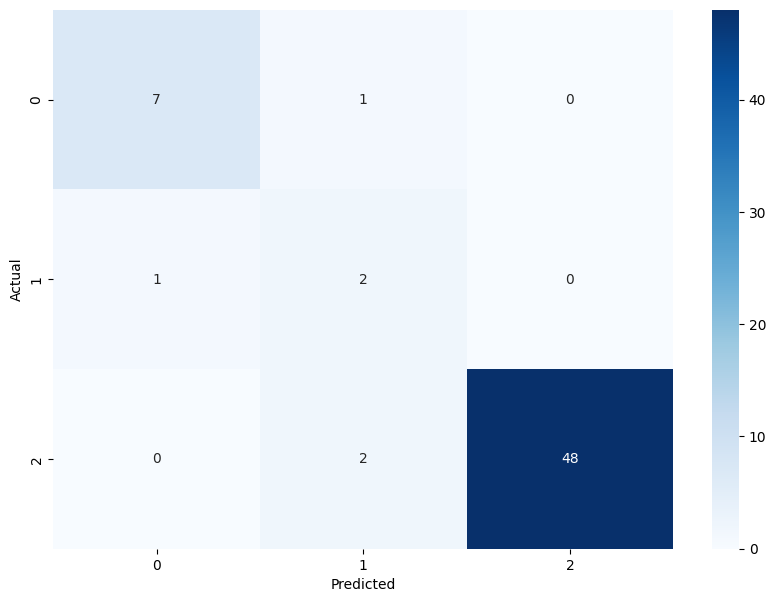

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))
cm_logreg=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm_logreg, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,   
    max_depth=None,     
    random_state=42
)
rf_model.fit(x_train, y_train)
y_pred_rf=rf_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9344262295081968
              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.40      0.67      0.50         3
           2       1.00      0.96      0.98        50

    accuracy                           0.93        61
   macro avg       0.76      0.83      0.78        61
weighted avg       0.95      0.93      0.94        61



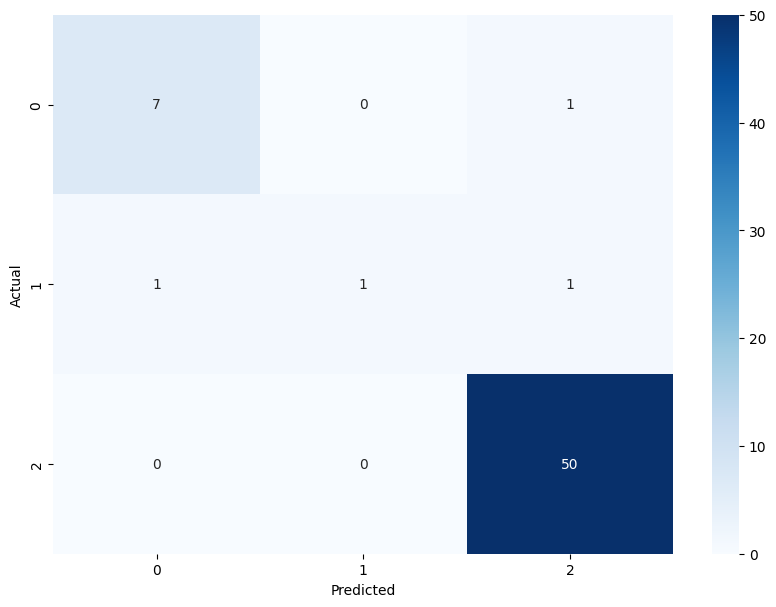

In [45]:
cm_logreg=confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10,7))
sns.heatmap(cm_logreg, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [48]:
features = [
    'Log_Total_inventory', 'Log_NCL', 'Current_ratio',
    'Log_Pexpenses','Log_RE','Log_Operatin_profit','Log_Equity','Log_cash','Payable_turnover','Asset_turnover',
    'ROA','Net_profit_margin','Receivable_turnover','Cash_ratio','ROE'
]
x_next=df[features]
x_next=x_next.fillna(x_next.mean())
y_next=y

In [49]:
x_tr, x_t, y_tr, y_t=train_test_split(x_next, y, stratify=y, random_state=42)
scaler1=StandardScaler()
x_tr=scaler1.fit_transform(x_tr)
x_t=scaler1.transform(x_t)


In [ ]:

model1=LogisticRegression(class_weight='balanced')
model1.fit(x_tr, y_tr)
y_pred_1=model1.predict(x_t)


Logistic Regression Accuracy: 0.8311688311688312
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67        10
           1       0.17      0.50      0.25         4
           2       0.98      0.89      0.93        63

    accuracy                           0.83        77
   macro avg       0.63      0.66      0.62        77
weighted avg       0.91      0.83      0.86        77



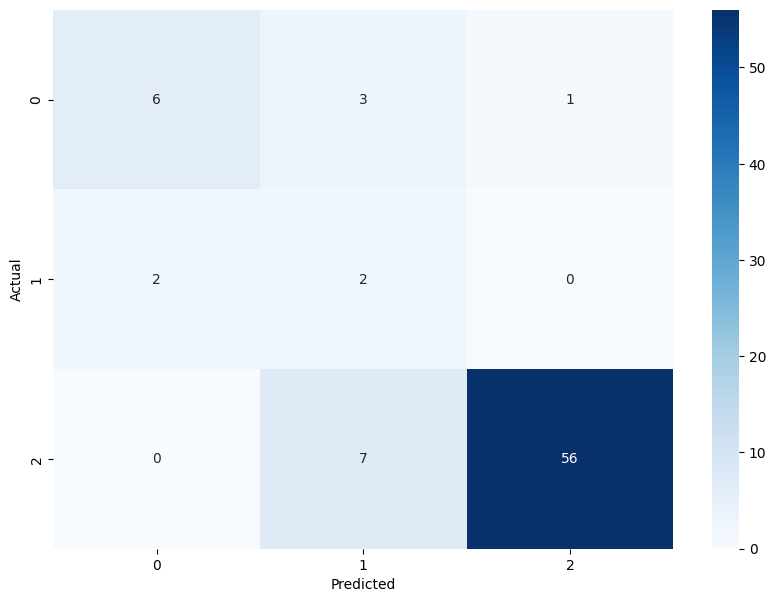

In [52]:
print('Logistic Regression Accuracy:', accuracy_score(y_t, y_pred_1))
print('Classification Report:\n', classification_report(y_t, y_pred_1))
cm_log=confusion_matrix(y_t, y_pred_1)
plt.figure(figsize=(10,7))
sns.heatmap(cm_log, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [55]:
from sklearn.ensemble import RandomForestClassifier
rf_model_1 = RandomForestClassifier(
    n_estimators=200,   
    max_depth=5,     
    random_state=42
)
rf_model_1.fit(x_tr, y_tr)
y_pred_rf1=rf_model_1.predict(x_t)

Logistic Regression Accuracy: 0.922077922077922
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       0.00      0.00      0.00         4
           2       0.94      1.00      0.97        63

    accuracy                           0.92        77
   macro avg       0.58      0.60      0.59        77
weighted avg       0.87      0.92      0.90        77



C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classif

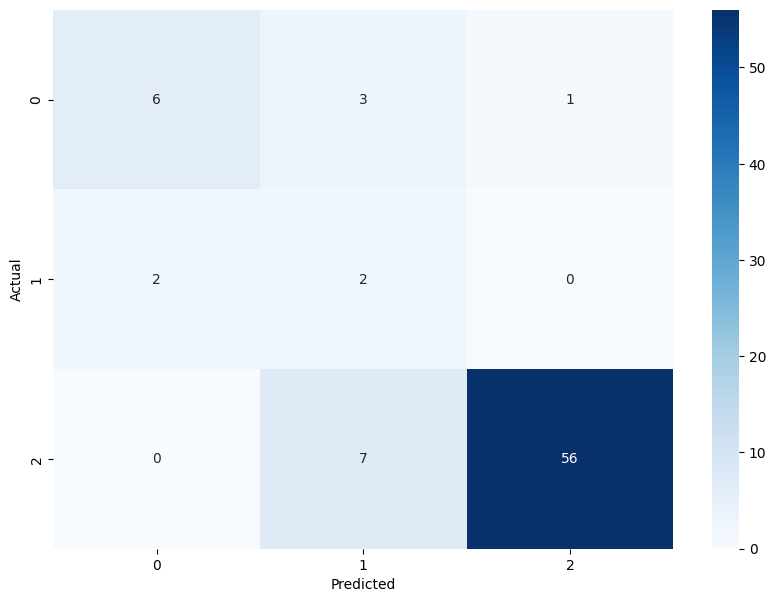

In [56]:
print('Logistic Regression Accuracy:', accuracy_score(y_t, y_pred_rf1))
print('Classification Report:\n', classification_report(y_t, y_pred_rf1))
cm_log_rf1=confusion_matrix(y_t, y_pred_rf1)
plt.figure(figsize=(10,7))
sns.heatmap(cm_log, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [57]:
corr_matrix=df.corr()
corr_matrix

,Station_ID,Year,Quarter,Log_RV_PPE,Log_Depreciation_PPE,Log_Total_NCA,Log_Total_inventory,Log_TR,Log_cash,Log_Total_CA,...,Equity_ratio,Debt to equity,Debt ratio,ROA,ROE,Net_profit_margin,Asset_turnover,Receivable_turnover,Payable_turnover,Target
Station_ID,1.000000,0.042820,0.010840,-0.608140,-0.465755,-0.697408,-0.238481,-0.264335,-0.127441,-0.353318,...,0.259376,-0.259376,-0.259376,0.330569,0.020798,-0.024017,0.357650,-0.071350,-0.016060,0.254955
Year,0.042820,1.000000,-0.032272,0.189000,0.266975,0.085760,0.268918,0.364094,0.085530,0.392057,...,-0.289283,0.289283,0.289283,-0.093762,-0.135429,-0.016779,-0.114644,-0.181446,-0.140906,-0.130070
Quarter,0.010840,-0.032272,1.000000,0.008265,0.012631,0.006446,0.033328,0.026347,0.076354,0.017627,...,-0.047259,0.047259,0.047259,-0.000245,-0.119946,0.002372,0.308731,0.166220,0.258750,-0.016190
Log_RV_PPE,-0.608140,0.189000,0.008265,1.000000,0.925700,0.728788,0.734296,0.697623,0.394820,0.764826,...,-0.488952,0.488952,0.488952,-0.219873,-0.172464,-0.133828,-0.252644,0.042419,0.237309,-0.127986
Log_Depreciation_PPE,-0.465755,0.266975,0.012631,0.925700,1.000000,0.586466,0.801064,0.709685,0.379311,0.740334,...,-0.531002,0.531002,0.531002,-0.126441,-0.217267,-0.165276,-0.094093,0.096535,0.261652,-0.133993
Log_Total_NCA,-0.697408,0.085760,0.006446,0.728788,0.586466,1.000000,0.587626,0.635226,0.395167,0.736897,...,-0.293707,0.293707,0.293707,-0.201226,-0.151710,0.103839,-0.426306,-0.055349,0.113274,-0.030941
Log_Total_inventory,-0.238481,0.268918,0.033328,0.734296,0.801064,0.587626,1.000000,0.821682,0.375637,0.833269,...,-0.532062,0.532062,0.532062,-0.113584,-0.292042,-0.099429,0.009050,0.135031,0.094827,-0.100597
Log_TR,-0.264335,0.364094,0.026347,0.697623,0.709685,0.635226,0.821682,1.000000,0.514523,0.931235,...,-0.366796,0.366796,0.366796,0.058715,-0.415400,0.018383,-0.176746,-0.168281,0.157554,0.159056
Log_cash,-0.127441,0.085530,0.076354,0.394820,0.379311,0.395167,0.375637,0.514523,1.000000,0.505780,...,-0.173947,0.173947,0.173947,0.127448,-0.050151,0.073768,-0.065299,-0.030646,0.221889,0.106434
Log_Total_CA,-0.353318,0.392057,0.017627,0.764826,0.740334,0.736897,0.833269,0.931235,0.505780,1.000000,...,-0.464438,0.464438,0.464438,-0.102460,-0.295709,0.014933,-0.215578,-0.088050,0.138051,0.078880


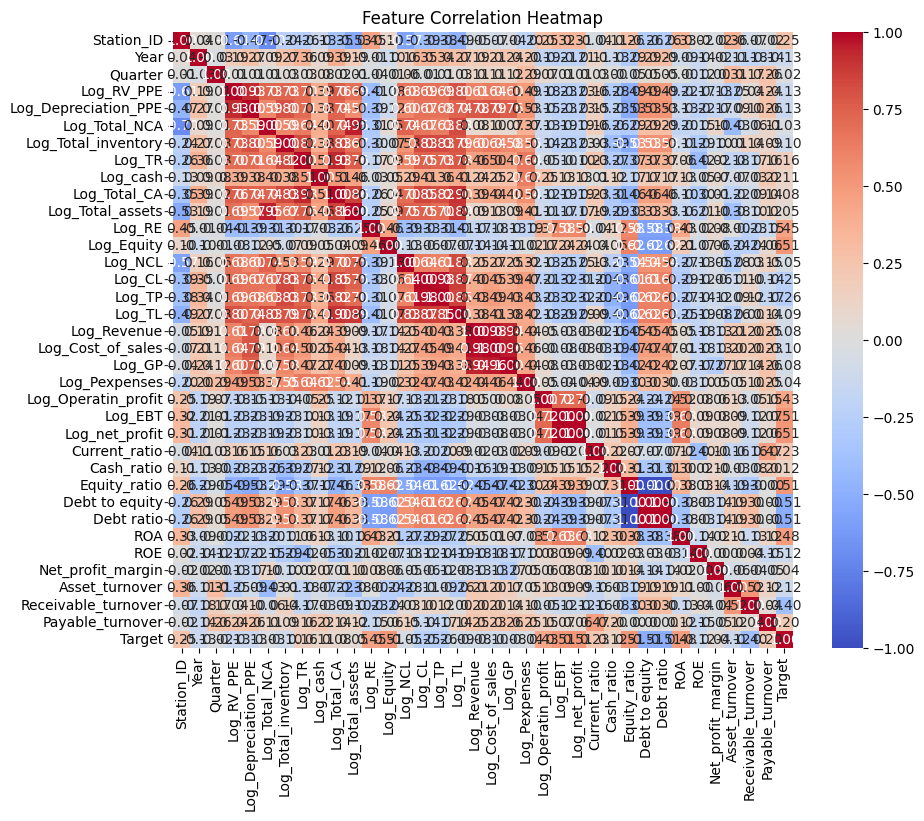

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()

Target                  1.000000
Equity_ratio            0.510742
Log_EBT                 0.510344
Log_Equity              0.509166
Log_net_profit          0.508816
ROA                     0.481672
Log_RE                  0.448232
Log_Operatin_profit     0.431428
Station_ID              0.254955
Current_ratio           0.231756
Payable_turnover        0.195920
Log_TR                  0.159056
Cash_ratio              0.121941
Log_cash                0.106434
Log_Total_CA            0.078880
Log_Total_assets        0.052672
Net_profit_margin       0.036777
Quarter                -0.016190
Log_Total_NCA          -0.030941
Log_Pexpenses          -0.036352
Log_NCL                -0.052404
Log_GP                 -0.078093
Log_Revenue            -0.080806
Log_TL                 -0.085328
Log_Total_inventory    -0.100597
Log_Cost_of_sales      -0.101432
ROE                    -0.118446
Asset_turnover         -0.124463
Log_RV_PPE             -0.127986
Year                   -0.130070
Log_Deprec

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11744\4145703797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.index, y=target_corr.values, palette='viridis')


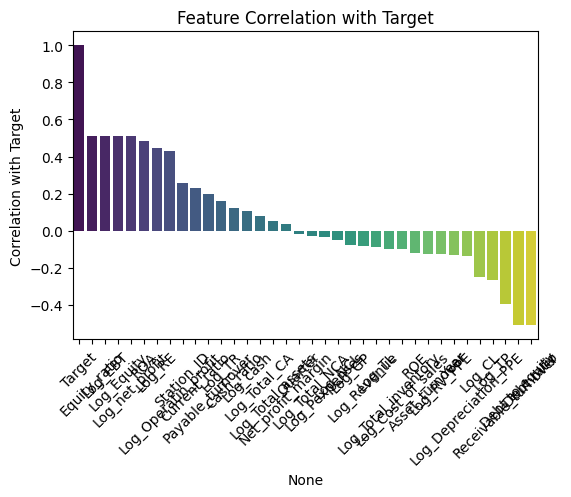

In [59]:
target_corr = corr_matrix['Target'].sort_values(ascending=False)
print(target_corr)

# Visualize
plt.figure(figsize=(6,4))
sns.barplot(x=target_corr.index, y=target_corr.values, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Correlation with Target")
plt.title("Feature Correlation with Target")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11744\3595493540.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features, y=target_corr[top_features].values, palette='viridis')


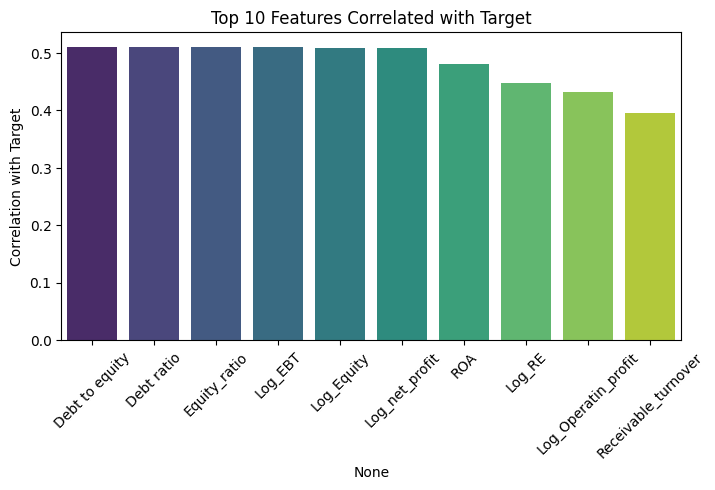

In [60]:
# Get correlation with target
target_corr = df.corr()['Target'].abs().sort_values(ascending=False)

# Pick top N features (excluding the target itself)
top_features = target_corr[1:11].index  # top 10 features

plt.figure(figsize=(8,4))
sns.barplot(x=top_features, y=target_corr[top_features].values, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Correlation with Target")
plt.title("Top 10 Features Correlated with Target")
plt.show()

In [62]:
df.columns

Index(['Station_ID', 'Year', 'Quarter', 'Log_RV_PPE', 'Log_Depreciation_PPE',
       'Log_Total_NCA', 'Log_Total_inventory', 'Log_TR', 'Log_cash',
       'Log_Total_CA', 'Log_Total_assets', 'Log_RE', 'Log_Equity', 'Log_NCL',
       'Log_CL', 'Log_TP', 'Log_TL', 'Log_Revenue', 'Log_Cost_of_sales',
       'Log_GP', 'Log_Pexpenses', 'Log_Operatin_profit', 'Log_EBT',
       'Log_net_profit', 'Current_ratio', 'Cash_ratio', 'Equity_ratio',
       'Debt to equity', 'Debt ratio', 'ROA', 'ROE', 'Net_profit_margin',
       'Asset_turnover', 'Receivable_turnover', 'Payable_turnover', 'Target'],
      dtype='object')

In [ ]:
corr_with_target = df.corr()['Target']

# Take absolute values to find strongest correlations
abs_corr = corr_with_target.abs()
abs_corr = abs_corr.drop('Target')  

# Get top 10 features
top_10_features = abs_corr.sort_values(ascending=False)
print(top_10_features)

Debt to equity          0.510742
Debt ratio              0.510742
Equity_ratio            0.510742
Log_EBT                 0.510344
Log_Equity              0.509166
Log_net_profit          0.508816
ROA                     0.481672
Log_RE                  0.448232
Log_Operatin_profit     0.431428
Receivable_turnover     0.396172
Log_TP                  0.264442
Station_ID              0.254955
Log_CL                  0.248451
Current_ratio           0.231756
Payable_turnover        0.195920
Log_TR                  0.159056
Log_Depreciation_PPE    0.133993
Year                    0.130070
Log_RV_PPE              0.127986
Asset_turnover          0.124463
Cash_ratio              0.121941
ROE                     0.118446
Log_cash                0.106434
Log_Cost_of_sales       0.101432
Log_Total_inventory     0.100597
Log_TL                  0.085328
Log_Revenue             0.080806
Log_Total_CA            0.078880
Log_GP                  0.078093
Log_Total_assets        0.052672
Log_NCL   

In [69]:
feature_names = x.columns.tolist()
coefs = model.coef_
if coefs.shape[0] == 1:
    feature_coefs = coefs[0]
else:
    feature_coefs = coefs.mean(axis=0)

# Create DataFrame with proper feature names
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': feature_coefs
}).sort_values(by='Coefficient', key=abs, ascending=False)
print(coef_df.head(10))

                Feature   Coefficient
32       Asset_turnover -1.110223e-15
33  Receivable_turnover -9.992007e-16
29                  ROA  9.251859e-16
12           Log_Equity  8.696747e-16
27       Debt to equity -8.141636e-16
28           Debt ratio -8.141636e-16
11               Log_RE  8.141636e-16
26         Equity_ratio  6.291264e-16
1                  Year  5.366078e-16
2               Quarter -5.285124e-16


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11744\3999683289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


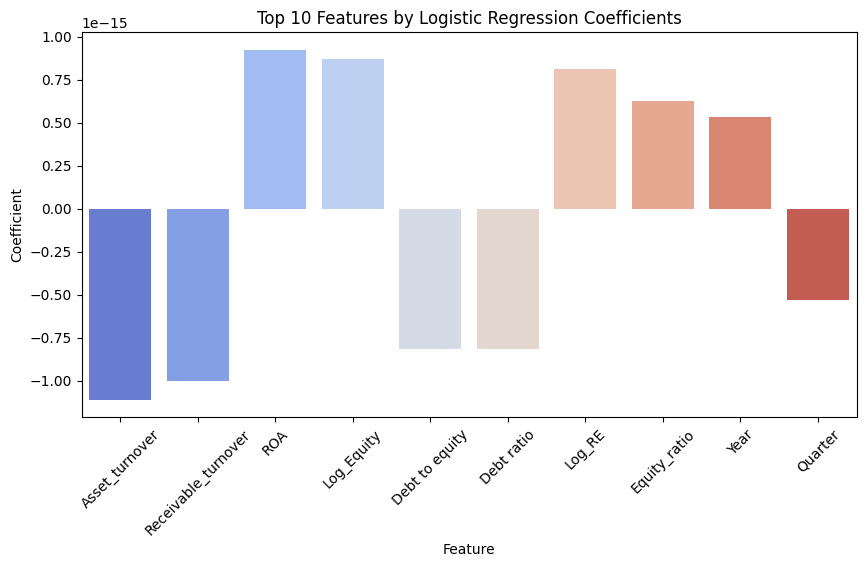

In [70]:
top_n = 10
plt.figure(figsize=(10,5))
sns.barplot(
    x='Feature', 
    y='Coefficient', 
    data=coef_df.head(top_n), 
    palette='coolwarm'
)
plt.xticks(rotation=45)
plt.title("Top 10 Features by Logistic Regression Coefficients")
plt.show()

In [ ]:
coef_df = pd.DataFrame(
    rf_model_1.,
    columns=feature_names
)

# Optional: add class labels as rows
if model.coef_.shape[0] > 1:
    coef_df['Class'] = [f'Class_{i}' for i in range(model.coef_.shape[0])]
    coef_df = coef_df.set_index('Class')

# Show all coefficients
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.width', None)        # auto width
print(coef_df)

AttributeError: 'RandomForestClassifier' object has no attribute 'coef_'

In [73]:
# Transpose for easier view
coef_df_display = pd.DataFrame(model.coef_, columns=feature_names)
if coef_df_display.shape[0] > 1:
    coef_df_display.index = [f'Class_{i}' for i in range(coef_df_display.shape[0])]

# Show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Transpose if needed
print(coef_df_display.T)

                       Class_0   Class_1   Class_2
Station_ID           -0.129165 -0.335071  0.464236
Year                 -0.964897  1.097624 -0.132727
Quarter               0.489628 -0.513685  0.024057
Log_RV_PPE            0.937866 -0.718518 -0.219348
Log_Depreciation_PPE  0.013255  0.098268 -0.111523
Log_Total_NCA        -0.022662  0.212525 -0.189863
Log_Total_inventory  -0.067097  0.376314 -0.309217
Log_TR               -0.760177 -0.480228  1.240405
Log_cash             -0.297584  0.221243  0.076341
Log_Total_CA         -1.394987 -0.149626  1.544613
Log_Total_assets     -0.411588 -0.205631  0.617219
Log_RE                0.200914 -0.740105  0.539191
Log_Equity           -0.499713  0.972931 -0.473218
Log_NCL              -0.847513  0.321522  0.525990
Log_CL                0.982485 -0.636490 -0.345995
Log_TP                0.930387 -0.034921 -0.895466
Log_TL               -0.193663 -0.061501  0.255165
Log_Revenue           0.242908 -0.178447 -0.064461
Log_Cost_of_sales     0.291751 

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model_1.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

ValueError: All arrays must be of the same length

In [ ]:
top_n = 10  # show top 10 features
plt.figure(figsize=(8,5))
sns.barplot(
    x='Feature', 
    y='Importance', 
    data=feature_importances.head(top_n),
    palette='viridis'
)
plt.xticks(rotation=45)
plt.title("Top 10 Feature Importances in Random Forest")
plt.show()